# Classic models (CNN, brza rezolucija) — vodič kroz notebook

Isti pipeline kao `classic_models_cnn.ipynb`, samo sa nižom rezolucijom mel-spektrograma (64 mel bina,
duplo veći hop_length) — ~4x brže po uzorku na CPU-u. Odvojen notebook da se ne miješa sa
`classic_models_cnn.ipynb` (koji ima svoj live trening u toku na staroj rezoluciji).

Segmenti su **10s** (`config.SEGMENT_DURATION`).

PyTorch je CPU-only na ovoj mašini (nema CUDA) — trening je zato sporiji nego na GPU-u; model je namjerno
mali da to ostane izvodljivo.

In [1]:
%load_ext autoreload
%autoreload 2

# Ucitavanje podataka

## Priprema metapodataka

Pregled izvorne tabele i raspodjele kompozitora nalazi se u [metadata.ipynb](metadata.ipynb).
`load_metadata()` iz `dataset.py` učitava CSV, formira `work_id` kao `composer + " | " + composition`
i zadržava kompozitore sa najmanje `MIN_WORKS_PER_COMPOSER` različitih djela (podrazumijevano 5, iz `config.py`).
Svi stavovi istog djela tako ostaju u istoj grupi tokom evaluacije.

Ova sveska se izvršava samostalno; nije potrebno prethodno pokretati `metadata.ipynb`.

In [ ]:
import numpy as np
import pandas as pd

from dataset import load_metadata
from paths import AUDIO_DIR

metadata_filtered = load_metadata()

In [8]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


---

## Mel-spektrogram dataset

`make_spectrogram_dataset` (u `spectrograms.py`) radi isto što i `make_dataset`/`make_midi_dataset` — učita
audio, isiječe na segmente, ali umjesto ručnih atributa računa `extract_melspec` (64 mel bina ×
~431 vremenski frame po segmentu, log-dB skala). Rezultat je keširan na disk (invalidira se automatski
ako se promijeni `spectrograms.py`).

Rezolucija je namjerno niža nego kod klasičnog `feature_engineering.py` pipeline-a (koji koristi
`n_mels`/`hop_length` iz `config.py`) — na CPU treningu ovo je ~4x brže po uzorku (izmjereno), uz
zanemarljiv gubitak informacije za ovaj zadatak (nije potrebna fina rezolucija tona/vremena za
prepoznavanje kompozitorskog stila).

Pošto su `SEGMENT_DURATION == MIN_LAST_DURATION == 10`, zadržavaju se samo puni 10s segmenti — svi imaju
identičnu dužinu, pa je `X` običan 3D numpy niz (N, 64, 431), bez potrebe za paddingom.

In [9]:
from spectrograms import make_spectrogram_dataset

X, y, groups = make_spectrogram_dataset(metadata_filtered, AUDIO_DIR)

print(X.shape)

Processing spectrograms:   0%|          | 0/302 [00:00<?, ?it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing spectrograms: 100%|██████████| 302/302 [33:53<00:00,  6.73s/it]


(11096, 64, 431)


---

## Train/val split

Pun 5-fold `StratifiedGroupKFold` (kao kod klasičnih modela) bi značio 5x treniranje CNN-a — na CPU-u
predugo za iterativno eksperimentisanje. Za sada radimo **jedan** group-aware split (`GroupShuffleSplit` —
segmenti istog `work_id` ne smiju biti i u train i u val). Kad se arhitektura/hiperparametri skoro finalizuju,
vrijedi ponoviti sa punim CV radi pouzdanije ocjene.

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

from evaluation import make_sample_weights, soft_vote_predictions

le = LabelEncoder()
y_enc = le.fit_transform(y)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y_enc, groups))

X_train, y_train, groups_train = X[train_idx], y_enc[train_idx], groups[train_idx]
X_val, y_val, groups_val = X[val_idx], y[val_idx], groups[val_idx]

sample_weights = make_sample_weights(y[train_idx], groups_train)

print("train segments:", len(X_train), "val segments:", len(X_val))

train segments: 8919 val segments: 2177


---

## Model i trening

Mali CNN (`SimpleCNN` u `nn_utils.py`): 3 conv+BN+ReLU+maxpool bloka, pa global average pooling i dropout
prije finalnog linearnog sloja — namjerno malo parametara zbog svega 113 djela. `SpecAugment` (nasumično
maskiranje frekvencijskih/vremenskih traka) je uključen samo na trening skupu, kao augmentacija.
`sample_weights` (isti mehanizam kao kod klasičnih modela) ide kroz `WeightedRandomSampler`, umjesto direktno
u loss funkciju.

device: cpu


epoch 1/20: 100%|██████████| 140/140 [03:02<00:00,  1.30s/it, acc=0.347, loss=1.46]


epoch 1/20: train_loss=1.4626 train_acc=0.3467 val_loss=1.5354 val_acc=0.1185


epoch 2/20: 100%|██████████| 140/140 [03:31<00:00,  1.51s/it, acc=0.46, loss=1.27] 


epoch 2/20: train_loss=1.2684 train_acc=0.4604 val_loss=1.5665 val_acc=0.1768


...

epoch 18/20: train_loss=0.7509 train_acc=0.7038 val_loss=1.8156 val_acc=0.3142


epoch 19/20: 100%|██████████| 140/140 [02:57<00:00,  1.27s/it, acc=0.718, loss=0.725]


epoch 19/20: train_loss=0.7252 train_acc=0.7176 val_loss=1.8305 val_acc=0.3620


epoch 20/20: 100%|██████████| 140/140 [02:55<00:00,  1.26s/it, acc=0.732, loss=0.7]  


epoch 20/20: train_loss=0.7001 train_acc=0.7323 val_loss=1.2788 val_acc=0.4658


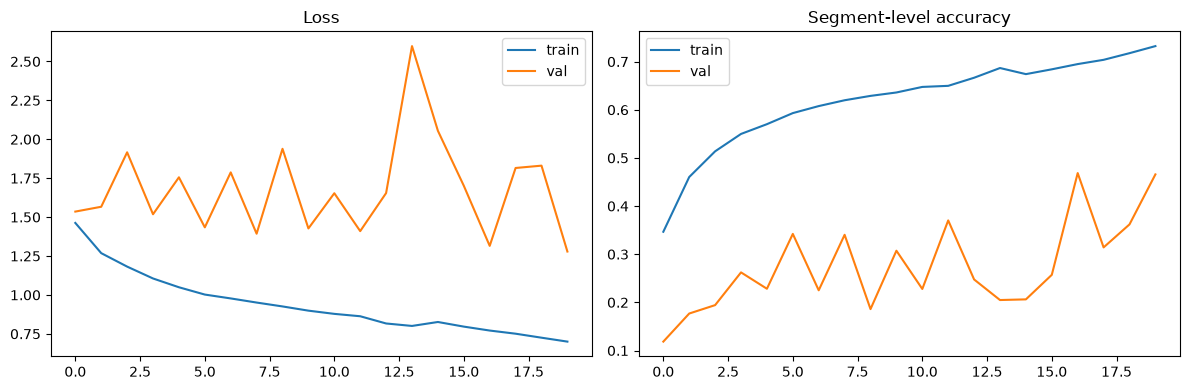

In [11]:
import torch

from nn_utils import SpectrogramDataset, SimpleCNN, train_model, plot_history

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

train_ds = SpectrogramDataset(X_train, y_train, augment=True)
val_ds = SpectrogramDataset(X_val, le.transform(y_val), augment=False)

model = SimpleCNN(n_classes=len(le.classes_))

history = train_model(
    model, train_ds, val_ds,
    sample_weights=sample_weights,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    device=device,
    checkpoint_path="checkpoints/cnn_fast_best.pt"
)

plot_history(history)

---

## Work-level evaluacija

Model predviđa po segmentu; `soft_vote_predictions` (ista funkcija iz `evaluation.py` koju smo definisali za
klasične modele, do sad neiskorištena) prosječi softmax vjerovatnoće svih segmenata jednog djela i uzme
najvjerovatniju klasu — konzistentno sa `majority_vote_prediction` pristupom kod ostalih modela, samo
iskorišćava i "koliko je model siguran", ne samo tvrdu predikciju.

              precision    recall  f1-score   support

        Bach       1.00      0.71      0.83         7
   Beethoven       0.70      0.58      0.64        12
      Brahms       0.50      1.00      0.67         1
      Mozart       0.00      0.00      0.00         1
    Schubert       0.00      0.00      0.00         2

    accuracy                           0.57        23
   macro avg       0.44      0.46      0.43        23
weighted avg       0.69      0.57      0.61        23



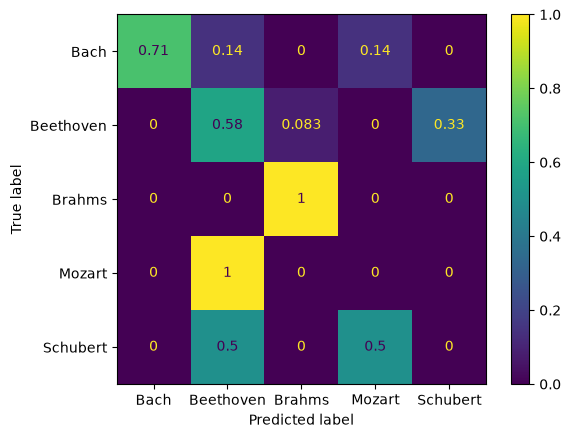

In [12]:
from sklearn import metrics
from matplotlib import pyplot as plt

from nn_utils import predict_probs

probs = predict_probs(model, X_val, device=device)

work_true, work_pred = soft_vote_predictions(y_val, probs, groups_val, le.classes_)

print(metrics.classification_report(work_true, work_pred))

metrics.ConfusionMatrixDisplay.from_predictions(work_true, work_pred, normalize="true")
plt.show()